In [2]:
import pandas as pd
import numpy as np

from sklearn.cluster import DBSCAN

import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(
    "../data/cleaned_parking_data.csv"
)

C:\Users\priya\AppData\Local\Temp\ipykernel_31432\1084111289.py:1: DtypeWarning: Columns (0: data_sent_to_scita_timestamp) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


In [4]:
coords = df[
    ['latitude','longitude']
]

In [5]:
sample_df = df.sample(
    n=20000,
    random_state=42
)

coords = sample_df[['latitude','longitude']]

In [6]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.003,
    min_samples=50
)

sample_df['cluster'] = dbscan.fit_predict(coords)

In [7]:
sample_df['cluster'].value_counts()

cluster
 2     5258
-1     3718
 4     1876
 1     1619
 0     1068
 5      985
 31     399
 3      304
 12     267
 20     214
 35     212
 34     199
 10     198
 14     194
 8      189
 24     183
 17     168
 13     149
 11     138
 29     134
 6      133
 19     127
 27     125
 7      122
 26     122
 16     121
 22     121
 37     109
 40     102
 23      97
 38      82
 33      80
 32      79
 9       76
 15      71
 36      69
 30      68
 46      68
 28      65
 42      65
 45      64
 18      61
 39      59
 25      58
 43      58
 41      54
 44      54
 21      53
 48      51
 49      50
 50      34
 47      30
Name: count, dtype: int64

In [8]:
n_clusters = len(
    set(sample_df['cluster'])
) - (1 if -1 in sample_df['cluster'].values else 0)

print("Number of Hotspots:", n_clusters)

Number of Hotspots: 51


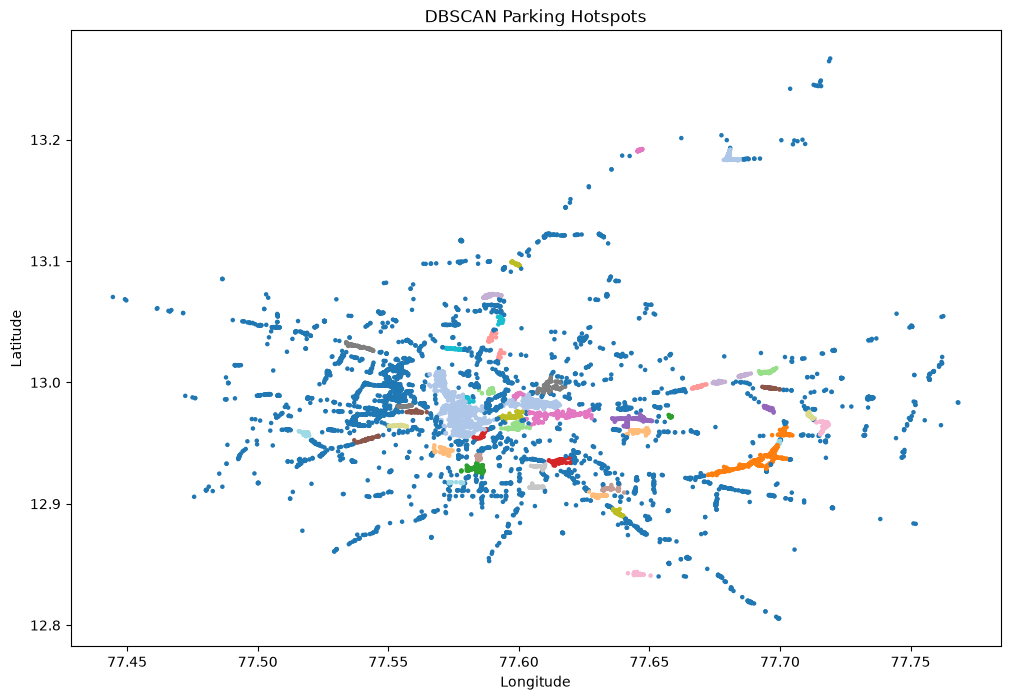

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))

plt.scatter(
    sample_df['longitude'],
    sample_df['latitude'],
    c=sample_df['cluster'],
    cmap='tab20',
    s=5
)

plt.title("DBSCAN Parking Hotspots")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [10]:
print("Number of Hotspots:", n_clusters)

Number of Hotspots: 51


In [11]:
vehicle_weight = {
    'SCOOTER':1,
    'MOTOR CYCLE':1,
    'MOPED':1,
    'PASSENGER AUTO':2,
    'GOODS AUTO':3,
    'CAR':3,
    'MAXI-CAB':3,
    'VAN':3,
    'JEEP':3,
    'BUS (BMTC/KSRTC)':5,
    'PRIVATE BUS':5,
    'SCHOOL VEHICLE':5,
    'TOURIST BUS':5,
    'LORRY/GOODS VEHICLE':6,
    'HGV':6,
    'TANKER':7,
    'TRACTOR':4
}

In [12]:
violation_weight = {
    'NO PARKING':2,
    'WRONG PARKING':3,
    'PARKING IN A MAIN ROAD':5,
    'DOUBLE PARKING':6,
    'PARKING ON FOOTPATH':2,
    'PARKING NEAR ROAD CROSSING':5
}

In [13]:
sample_df['vehicle_score'] = (
    sample_df['vehicle_type']
    .map(vehicle_weight)
    .fillna(2)
)

sample_df['violation_score'] = (
    sample_df['violation_type']
    .map(violation_weight)
    .fillna(2)
)

In [14]:
sample_df['junction_factor'] = np.where(
    sample_df['junction_name'] == 'No Junction',
    1,
    2
)

In [15]:
sample_df['impact_score'] = (
    sample_df['vehicle_score']
    *
    sample_df['violation_score']
    *
    sample_df['junction_factor']
)

In [16]:
hotspot_rank = (
    sample_df
    .groupby('cluster')['impact_score']
    .mean()
    .sort_values(ascending=False)
)

hotspot_rank.head(10)

cluster
47    12.800000
39    11.457627
26    10.655738
19    10.622047
30     9.808824
50     9.794118
2      9.660137
1      9.659666
40     9.578431
15     9.521127
Name: impact_score, dtype: float64

In [17]:
hotspot_rank.head(10)

cluster
47    12.800000
39    11.457627
26    10.655738
19    10.622047
30     9.808824
50     9.794118
2      9.660137
1      9.659666
40     9.578431
15     9.521127
Name: impact_score, dtype: float64

In [18]:
hotspot_locations = (
    sample_df
    .groupby('cluster')
    .agg({
        'latitude':'mean',
        'longitude':'mean',
        'police_station':'first',
        'impact_score':'mean'
    })
)

hotspot_locations.sort_values(
    by='impact_score',
    ascending=False
).head(10)

,latitude,longitude,police_station,impact_score
cluster,,,,
47,12.986608,77.580466,High ground,12.800000
39,12.930431,77.608136,Mico Layout,11.457627
26,12.953257,77.542311,Byatarayanapura,10.655738
19,12.996248,77.668571,Mahadevapura,10.622047
30,13.191225,77.646206,Chikkajala,9.808824
50,12.950522,77.699759,HAL Old Airport,9.794118
2,12.976444,77.576713,Upparpet,9.660137
1,13.001741,77.551821,Rajajinagar,9.659666
40,12.971751,77.597308,Cubbon Park,9.578431


In [19]:
sample_df['risk_level'] = pd.cut(
    sample_df['impact_score'],
    bins=[0,4,8,12,100],
    labels=[
        'Low',
        'Medium',
        'High',
        'Critical'
    ]
)

In [ ]:
vehicle_weight = {
    'SCOOTER':1,
    'MOTOR CYCLE':1,
    'MOPED':1,
    'PASSENGER AUTO':2,
    'GOODS AUTO':3,
    'CAR':3,
    'MAXI-CAB':3,
    'VAN':3,
    'JEEP':3,
    'BUS (BMTC/KSRTC)':5,
    'PRIVATE BUS':5,
    'SCHOOL VEHICLE':5,
    'TOURIST BUS':5,
    'LORRY/GOODS VEHICLE':6,
    'HGV':6,
    'TANKER':7,
    'TRACTOR':4
}

In [20]:
sample_df['risk_level'].value_counts()

risk_level
Low         6672
Medium      5990
High        4642
Critical    2696
Name: count, dtype: int64

In [21]:
X = sample_df[
    [
        'hour',
        'month',
        'vehicle_score',
        'violation_score',
        'junction_factor'
    ]
]

In [22]:
y = sample_df['risk_level']

In [23]:
hotspot_locations = (
    sample_df
    .groupby('cluster')
    .agg({
        'latitude':'mean',
        'longitude':'mean',
        'police_station':'first',
        'impact_score':'mean'
    })
)

hotspot_locations.sort_values(
    by='impact_score',
    ascending=False
).head(10)

,latitude,longitude,police_station,impact_score
cluster,,,,
47,12.986608,77.580466,High ground,12.800000
39,12.930431,77.608136,Mico Layout,11.457627
26,12.953257,77.542311,Byatarayanapura,10.655738
19,12.996248,77.668571,Mahadevapura,10.622047
30,13.191225,77.646206,Chikkajala,9.808824
50,12.950522,77.699759,HAL Old Airport,9.794118
2,12.976444,77.576713,Upparpet,9.660137
1,13.001741,77.551821,Rajajinagar,9.659666
40,12.971751,77.597308,Cubbon Park,9.578431


In [24]:
sample_df['risk_level'] = pd.cut(
    sample_df['impact_score'],
    bins=[0,4,8,12,100],
    labels=['Low','Medium','High','Critical']
)

sample_df['risk_level'].value_counts()

risk_level
Low         6672
Medium      5990
High        4642
Critical    2696
Name: count, dtype: int64

In [26]:
hotspot_summary = (
    sample_df.groupby('cluster')
    .agg({
        'impact_score':'mean',
        'cluster':'size'
    })
)

hotspot_summary.columns = [
    'avg_impact',
    'violation_count'
]

hotspot_summary['severity_score'] = (
    hotspot_summary['avg_impact']
    *
    np.log1p(hotspot_summary['violation_count'])
)

hotspot_summary.sort_values(
    'severity_score',
    ascending=False
).head(10)

,avg_impact,violation_count,severity_score
cluster,,,
2,9.660137,5258,82.765118
1,9.659666,1619,71.386688
4,8.611407,1876,64.907880
-1,7.243948,3718,59.554021
19,10.622047,127,51.538495
26,10.655738,122,51.277374
0,7.292135,1068,50.858841
3,8.401316,304,48.058146
39,11.457627,59,46.911473


In [27]:
X = sample_df[
    [
        'hour',
        'month',
        'vehicle_score',
        'violation_score',
        'junction_factor'
    ]
]

In [29]:
y = sample_df['risk_level']

In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [32]:
pred = rf.predict(X_test)

In [33]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       542
        High       1.00      1.00      1.00       901
         Low       1.00      1.00      1.00      1382
      Medium       1.00      1.00      1.00      1175

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [34]:
sample_df['risk_level'] = pd.cut(
    sample_df['impact_score'],
    bins=[0,4,8,12,100],
    labels=[
        'Low',
        'Medium',
        'High',
        'Critical'
    ]
)

sample_df['risk_level'].value_counts()

risk_level
Low         6672
Medium      5990
High        4642
Critical    2696
Name: count, dtype: int64

In [35]:
hotspot_summary = (
    sample_df.groupby('cluster')
    .agg({
        'impact_score':'mean',
        'cluster':'size'
    })
)

hotspot_summary.columns = [
    'avg_impact',
    'violation_count'
]

hotspot_summary['severity_score'] = (
    hotspot_summary['avg_impact']
    *
    np.log1p(hotspot_summary['violation_count'])
)

hotspot_summary.sort_values(
    'severity_score',
    ascending=False
).head(10)

,avg_impact,violation_count,severity_score
cluster,,,
2,9.660137,5258,82.765118
1,9.659666,1619,71.386688
4,8.611407,1876,64.907880
-1,7.243948,3718,59.554021
19,10.622047,127,51.538495
26,10.655738,122,51.277374
0,7.292135,1068,50.858841
3,8.401316,304,48.058146
39,11.457627,59,46.911473


In [36]:
hotspot_summary = hotspot_summary[
    hotspot_summary.index != -1
]

In [37]:
from sklearn.model_selection import train_test_split

X = sample_df[
    [
        'hour',
        'month',
        'vehicle_score',
        'violation_score',
        'junction_factor'
    ]
]

y = sample_df['risk_level']

In [38]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [40]:
pred = rf.predict(X_test)

In [41]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        pred
    )
)

print(
    classification_report(
        y_test,
        pred
    )
)

Accuracy: 1.0
              precision    recall  f1-score   support

    Critical       1.00      1.00      1.00       539
        High       1.00      1.00      1.00       929
         Low       1.00      1.00      1.00      1334
      Medium       1.00      1.00      1.00      1198

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [42]:
importance = pd.DataFrame({
    'feature':X.columns,
    'importance':rf.feature_importances_
})

importance.sort_values(
    'importance',
    ascending=False
)

,feature,importance
2,vehicle_score,0.508242
3,violation_score,0.304766
4,junction_factor,0.178152
0,hour,0.006465
1,month,0.002376


In [43]:
accuracy_score(y_test,pred)

1.0

In [44]:
importance.sort_values(
    'importance',
    ascending=False
)

,feature,importance
2,vehicle_score,0.508242
3,violation_score,0.304766
4,junction_factor,0.178152
0,hour,0.006465
1,month,0.002376


In [47]:
import joblib

In [48]:
rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap

In [49]:
import joblib

joblib.dump(
    rf,
    "../models/risk_model.pkl"
)

['../models/risk_model.pkl']

In [50]:
sample_df.to_csv(
    "../data/final_dataset.csv",
    index=False
)

hotspot_locations.to_csv(
    "../data/hotspot_locations.csv"
)

In [51]:
importance.to_csv(
    "../data/feature_importance.csv",
    index=False
)